<a href="https://colab.research.google.com/github/HERO-DS/Computational-Drug-Discovery-LRRK2-gene/blob/main/CDD_ML_Part_2_LRRK2_Exploratory_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Exploratory Data Analysis**<br>
Descriptor Calculation and Exploratory Data Analysis.

## **Install conda and rdkit**

In [ ]:
# Cell 1: Fast RDKit installation (takes ~5 seconds)
!pip install -q rdkit

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd
import rdkit
print(f"RDKit Version: {rdkit.__version__}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
RDKit Version: 2026.03.5


In [ ]:
# Cell 2: Import libraries & read the CSV from Google Drive
import pandas as pd
from pathlib import Path

# Define the directory where your file lives in Drive
data_dir = Path('/content/drive/MyDrive/Colab Notebooks/data')
file_path = data_dir / 'LRRK2_Bioactivity_preprocessed_data.csv'

# Load the CSV file
df = pd.read_csv(file_path)

# Display the first few rows
df.head()

,molecule_chembl_id,canonical_smiles,standard_value,class
0,CHEMBL1771409,Cc1cc(N/N=C/c2ccc(O)c(O)c2)nc2ccccc12,13200.0,inactive
1,CHEMBL1771411,Cc1cc(N/N=C/c2ccncc2)nc2ccccc12,4100.0,intermediate
2,CHEMBL1933288,C[C@@H]1CCNC(=O)c2cc3ccc(C(=O)Nc4nc5ccccc5n4CC...,16.0,active
3,CHEMBL2012582,COc1cc(C(=O)N2CCC(N3CCN(C)CC3)CC2)ccc1Nc1ncc2c...,13.0,active
4,CHEMBL509032,COc1cc(N2CCC(N3CCN(C)CC3)CC2)ccc1Nc1ncc(Cl)c(N...,7.8,active


## **Load bioactivity data**

In [ ]:
import pandas as pd

In [ ]:
df_no_smiles = df.drop(columns='canonical_smiles')

In [ ]:
smiles = []

for i in df.canonical_smiles.tolist():
  cpd = str(i).split('.')
  cpd_longest = max(cpd, key = len)
  smiles.append(cpd_longest)

smiles = pd.Series(smiles, name = 'canonical_smiles')

In [ ]:
df_clean_smiles = pd.concat([df_no_smiles,smiles], axis=1)
df_clean_smiles

,molecule_chembl_id,standard_value,class,canonical_smiles
0,CHEMBL1771409,13200.0,inactive,Cc1cc(N/N=C/c2ccc(O)c(O)c2)nc2ccccc12
1,CHEMBL1771411,4100.0,intermediate,Cc1cc(N/N=C/c2ccncc2)nc2ccccc12
2,CHEMBL1933288,16.0,active,C[C@@H]1CCNC(=O)c2cc3ccc(C(=O)Nc4nc5ccccc5n4CC...
3,CHEMBL2012582,13.0,active,COc1cc(C(=O)N2CCC(N3CCN(C)CC3)CC2)ccc1Nc1ncc2c...
4,CHEMBL509032,7.8,active,COc1cc(N2CCC(N3CCN(C)CC3)CC2)ccc1Nc1ncc(Cl)c(N...
...,...,...,...,...
3778,CHEMBL6192175,830.0,active,CC(C)n1ccc(Nc2nc(N(C)[C@@H](C)C3CC3)c3cc[nH]c3...
3779,CHEMBL6190367,81.0,active,Cn1cc(Nc2nc(N[C@H]3CCc4ccccc43)c3nc[nH]c3n2)cn1
3780,CHEMBL6190371,6.0,active,CC(C)n1cc(Nc2nc(N[C@H]3CCc4ccccc43)c3nc[nH]c3n...
3781,CHEMBL6191498,6.0,active,CC(C)n1cc(Nc2nc(N[C@@H](C)C3CC3)c3c(C#N)c[nH]c...


## **Calculate Lipinski descriptors**
Christopher Lipinski, a scientist at Pfizer, came up with a set of rule-of-thumb for evaluating the **druglikeness** of compounds. Such druglikeness is based on the Absorption, Distribution, Metabolism and Excretion (ADME) that is also known as the pharmacokinetic profile. Lipinski analyzed all orally active FDA-approved drugs in the formulation of what is to be known as the **Rule-of-Five** or **Lipinski's Rule**.

The Lipinski's Rule stated the following:
* Molecular weight < 500 Dalton
* Octanol-water partition coefficient (LogP) < 5
* Hydrogen bond donors < 5
* Hydrogen bond acceptors < 10

### **Import libraries**

In [ ]:
import numpy as np
from rdkit import Chem
from rdkit.Chem import Descriptors, Lipinski

### **Calculate descriptors**

In [ ]:
# Inspired by: https://codeocean.com/explore/capsules?query=tag:data-curation

def lipinski(smiles, verbose=False):

    moldata= []
    for elem in smiles:
        mol=Chem.MolFromSmiles(elem)
        moldata.append(mol)

    baseData= np.arange(1,1)
    i=0
    for mol in moldata:

        desc_MolWt = Descriptors.MolWt(mol)
        desc_MolLogP = Descriptors.MolLogP(mol)
        desc_NumHDonors = Lipinski.NumHDonors(mol)
        desc_NumHAcceptors = Lipinski.NumHAcceptors(mol)

        row = np.array([desc_MolWt,
                        desc_MolLogP,
                        desc_NumHDonors,
                        desc_NumHAcceptors])

        if(i==0):
            baseData=row
        else:
            baseData=np.vstack([baseData, row])
        i=i+1

    columnNames=["MW","LogP","NumHDonors","NumHAcceptors"]
    descriptors = pd.DataFrame(data=baseData,columns=columnNames)

    return descriptors

In [ ]:
df_lipinski = lipinski(df_clean_smiles.canonical_smiles)
df_lipinski

,MW,LogP,NumHDonors,NumHAcceptors
0,293.326,3.40042,3.0,5.0
1,262.316,3.38422,1.0,4.0
2,458.566,3.88950,2.0,4.0
3,570.698,3.43870,1.0,9.0
4,614.216,5.02410,2.0,10.0
...,...,...,...,...
3778,339.447,3.71360,2.0,5.0
3779,346.398,2.92940,3.0,6.0
3780,374.452,3.97330,3.0,6.0
3781,350.430,3.56098,3.0,6.0


### **Combine DataFrames**

Let's take a look at the 2 DataFrames that will be combined.

In [ ]:
df_lipinski

,MW,LogP,NumHDonors,NumHAcceptors
0,293.326,3.40042,3.0,5.0
1,262.316,3.38422,1.0,4.0
2,458.566,3.88950,2.0,4.0
3,570.698,3.43870,1.0,9.0
4,614.216,5.02410,2.0,10.0
...,...,...,...,...
3778,339.447,3.71360,2.0,5.0
3779,346.398,2.92940,3.0,6.0
3780,374.452,3.97330,3.0,6.0
3781,350.430,3.56098,3.0,6.0


In [ ]:
df

,molecule_chembl_id,canonical_smiles,standard_value,class
0,CHEMBL1771409,Cc1cc(N/N=C/c2ccc(O)c(O)c2)nc2ccccc12,13200.0,inactive
1,CHEMBL1771411,Cc1cc(N/N=C/c2ccncc2)nc2ccccc12,4100.0,intermediate
2,CHEMBL1933288,C[C@@H]1CCNC(=O)c2cc3ccc(C(=O)Nc4nc5ccccc5n4CC...,16.0,active
3,CHEMBL2012582,COc1cc(C(=O)N2CCC(N3CCN(C)CC3)CC2)ccc1Nc1ncc2c...,13.0,active
4,CHEMBL509032,COc1cc(N2CCC(N3CCN(C)CC3)CC2)ccc1Nc1ncc(Cl)c(N...,7.8,active
...,...,...,...,...
3778,CHEMBL6192175,CC(C)n1ccc(Nc2nc(N(C)[C@@H](C)C3CC3)c3cc[nH]c3...,830.0,active
3779,CHEMBL6190367,Cn1cc(Nc2nc(N[C@H]3CCc4ccccc43)c3nc[nH]c3n2)cn1,81.0,active
3780,CHEMBL6190371,CC(C)n1cc(Nc2nc(N[C@H]3CCc4ccccc43)c3nc[nH]c3n...,6.0,active
3781,CHEMBL6191498,CC(C)n1cc(Nc2nc(N[C@@H](C)C3CC3)c3c(C#N)c[nH]c...,6.0,active


Now, let's combine the 2 DataFrame

In [ ]:
df_combined = pd.concat([df,df_lipinski], axis=1)

In [ ]:
df_combined

,molecule_chembl_id,canonical_smiles,standard_value,class,MW,LogP,NumHDonors,NumHAcceptors
0,CHEMBL1771409,Cc1cc(N/N=C/c2ccc(O)c(O)c2)nc2ccccc12,13200.0,inactive,293.326,3.40042,3.0,5.0
1,CHEMBL1771411,Cc1cc(N/N=C/c2ccncc2)nc2ccccc12,4100.0,intermediate,262.316,3.38422,1.0,4.0
2,CHEMBL1933288,C[C@@H]1CCNC(=O)c2cc3ccc(C(=O)Nc4nc5ccccc5n4CC...,16.0,active,458.566,3.88950,2.0,4.0
3,CHEMBL2012582,COc1cc(C(=O)N2CCC(N3CCN(C)CC3)CC2)ccc1Nc1ncc2c...,13.0,active,570.698,3.43870,1.0,9.0
4,CHEMBL509032,COc1cc(N2CCC(N3CCN(C)CC3)CC2)ccc1Nc1ncc(Cl)c(N...,7.8,active,614.216,5.02410,2.0,10.0
...,...,...,...,...,...,...,...,...
3778,CHEMBL6192175,CC(C)n1ccc(Nc2nc(N(C)[C@@H](C)C3CC3)c3cc[nH]c3...,830.0,active,339.447,3.71360,2.0,5.0
3779,CHEMBL6190367,Cn1cc(Nc2nc(N[C@H]3CCc4ccccc43)c3nc[nH]c3n2)cn1,81.0,active,346.398,2.92940,3.0,6.0
3780,CHEMBL6190371,CC(C)n1cc(Nc2nc(N[C@H]3CCc4ccccc43)c3nc[nH]c3n...,6.0,active,374.452,3.97330,3.0,6.0
3781,CHEMBL6191498,CC(C)n1cc(Nc2nc(N[C@@H](C)C3CC3)c3c(C#N)c[nH]c...,6.0,active,350.430,3.56098,3.0,6.0


### **Convert IC50 to pIC50**
To allow **IC50** data to be more uniformly distributed, we will convert **IC50** to the negative logarithmic scale which is essentially **-log10(IC50)**.

This custom function pIC50() will accept a DataFrame as input and will:
* Take the IC50 values from the ``standard_value`` column and converts it from nM to M by multiplying the value by 10$^{-9}$
* Take the molar value and apply -log10
* Delete the ``standard_value`` column and create a new ``pIC50`` column

In [ ]:
# https://github.com/chaninlab/estrogen-receptor-alpha-qsar/blob/master/02_ER_alpha_RO5.ipynb

import numpy as np

def pIC50(input):
    pIC50 = []

    for i in input['standard_value_norm']:
        molar = i*(10**-9) # Converts nM to M
        pIC50.append(-np.log10(molar))

    input['pIC50'] = pIC50
    x = input.drop('standard_value_norm', axis = 1)

    return x

Point to note: Values greater than 100,000,000 will be fixed at 100,000,000 otherwise the negative logarithmic value will become negative.

In [ ]:
df_combined.standard_value.describe()

,standard_value
count,3783.000000
mean,910.372559
std,5606.555082
min,0.001000
25%,13.000000
50%,55.000000
75%,204.000000
max,101080.000000


In [ ]:
-np.log10( (10**-9)* 100000000 )

np.float64(1.0)

In [ ]:
-np.log10( (10**-9)* 10000000000 )

np.float64(-1.0)

In [ ]:
def norm_value(input):
    norm = []

    for i in input['standard_value']:
        if i > 100000000:
          i = 100000000
        norm.append(i)

    input['standard_value_norm'] = norm
    x = input.drop('standard_value', axis=1)

    return x

We will first apply the norm_value() function so that the values in the standard_value column is normalized.

In [ ]:
df_norm = norm_value(df_combined)
df_norm

,molecule_chembl_id,canonical_smiles,class,MW,LogP,NumHDonors,NumHAcceptors,standard_value_norm
0,CHEMBL1771409,Cc1cc(N/N=C/c2ccc(O)c(O)c2)nc2ccccc12,inactive,293.326,3.40042,3.0,5.0,13200.0
1,CHEMBL1771411,Cc1cc(N/N=C/c2ccncc2)nc2ccccc12,intermediate,262.316,3.38422,1.0,4.0,4100.0
2,CHEMBL1933288,C[C@@H]1CCNC(=O)c2cc3ccc(C(=O)Nc4nc5ccccc5n4CC...,active,458.566,3.88950,2.0,4.0,16.0
3,CHEMBL2012582,COc1cc(C(=O)N2CCC(N3CCN(C)CC3)CC2)ccc1Nc1ncc2c...,active,570.698,3.43870,1.0,9.0,13.0
4,CHEMBL509032,COc1cc(N2CCC(N3CCN(C)CC3)CC2)ccc1Nc1ncc(Cl)c(N...,active,614.216,5.02410,2.0,10.0,7.8
...,...,...,...,...,...,...,...,...
3778,CHEMBL6192175,CC(C)n1ccc(Nc2nc(N(C)[C@@H](C)C3CC3)c3cc[nH]c3...,active,339.447,3.71360,2.0,5.0,830.0
3779,CHEMBL6190367,Cn1cc(Nc2nc(N[C@H]3CCc4ccccc43)c3nc[nH]c3n2)cn1,active,346.398,2.92940,3.0,6.0,81.0
3780,CHEMBL6190371,CC(C)n1cc(Nc2nc(N[C@H]3CCc4ccccc43)c3nc[nH]c3n...,active,374.452,3.97330,3.0,6.0,6.0
3781,CHEMBL6191498,CC(C)n1cc(Nc2nc(N[C@@H](C)C3CC3)c3c(C#N)c[nH]c...,active,350.430,3.56098,3.0,6.0,6.0


In [ ]:
df_norm.standard_value_norm.describe()

,standard_value_norm
count,3783.000000
mean,910.372559
std,5606.555082
min,0.001000
25%,13.000000
50%,55.000000
75%,204.000000
max,101080.000000


In [ ]:
df_final = pIC50(df_norm)
df_final

,molecule_chembl_id,canonical_smiles,class,MW,LogP,NumHDonors,NumHAcceptors,pIC50
0,CHEMBL1771409,Cc1cc(N/N=C/c2ccc(O)c(O)c2)nc2ccccc12,inactive,293.326,3.40042,3.0,5.0,4.879426
1,CHEMBL1771411,Cc1cc(N/N=C/c2ccncc2)nc2ccccc12,intermediate,262.316,3.38422,1.0,4.0,5.387216
2,CHEMBL1933288,C[C@@H]1CCNC(=O)c2cc3ccc(C(=O)Nc4nc5ccccc5n4CC...,active,458.566,3.88950,2.0,4.0,7.795880
3,CHEMBL2012582,COc1cc(C(=O)N2CCC(N3CCN(C)CC3)CC2)ccc1Nc1ncc2c...,active,570.698,3.43870,1.0,9.0,7.886057
4,CHEMBL509032,COc1cc(N2CCC(N3CCN(C)CC3)CC2)ccc1Nc1ncc(Cl)c(N...,active,614.216,5.02410,2.0,10.0,8.107905
...,...,...,...,...,...,...,...,...
3778,CHEMBL6192175,CC(C)n1ccc(Nc2nc(N(C)[C@@H](C)C3CC3)c3cc[nH]c3...,active,339.447,3.71360,2.0,5.0,6.080922
3779,CHEMBL6190367,Cn1cc(Nc2nc(N[C@H]3CCc4ccccc43)c3nc[nH]c3n2)cn1,active,346.398,2.92940,3.0,6.0,7.091515
3780,CHEMBL6190371,CC(C)n1cc(Nc2nc(N[C@H]3CCc4ccccc43)c3nc[nH]c3n...,active,374.452,3.97330,3.0,6.0,8.221849
3781,CHEMBL6191498,CC(C)n1cc(Nc2nc(N[C@@H](C)C3CC3)c3c(C#N)c[nH]c...,active,350.430,3.56098,3.0,6.0,8.221849


In [ ]:
df_final.pIC50.describe()

,pIC50
count,3783.000000
mean,7.270817
std,0.993059
min,3.995335
25%,6.690370
50%,7.259637
75%,7.886057
max,12.000000


Let's write this to CSV file.

In [ ]:
df_final.to_csv('/content/drive/MyDrive/Colab Notebooks/data/LRRK2_04_bioactivity_data_3class_pIC50.csv', index=False)

### **Removing the 'intermediate' bioactivity class**
Here, we will be removing the ``intermediate`` class from our data set.

In [ ]:
df_2class = df_final[df_final['class'] != 'intermediate']
df_2class

,molecule_chembl_id,canonical_smiles,class,MW,LogP,NumHDonors,NumHAcceptors,pIC50
0,CHEMBL1771409,Cc1cc(N/N=C/c2ccc(O)c(O)c2)nc2ccccc12,inactive,293.326,3.40042,3.0,5.0,4.879426
2,CHEMBL1933288,C[C@@H]1CCNC(=O)c2cc3ccc(C(=O)Nc4nc5ccccc5n4CC...,active,458.566,3.88950,2.0,4.0,7.795880
3,CHEMBL2012582,COc1cc(C(=O)N2CCC(N3CCN(C)CC3)CC2)ccc1Nc1ncc2c...,active,570.698,3.43870,1.0,9.0,7.886057
4,CHEMBL509032,COc1cc(N2CCC(N3CCN(C)CC3)CC2)ccc1Nc1ncc(Cl)c(N...,active,614.216,5.02410,2.0,10.0,8.107905
5,CHEMBL2170016,CNc1nc(Nc2ccc(C(=O)N3CCOCC3)cc2OC)ncc1Cl,active,377.832,2.39630,2.0,7.0,7.018181
...,...,...,...,...,...,...,...,...
3778,CHEMBL6192175,CC(C)n1ccc(Nc2nc(N(C)[C@@H](C)C3CC3)c3cc[nH]c3...,active,339.447,3.71360,2.0,5.0,6.080922
3779,CHEMBL6190367,Cn1cc(Nc2nc(N[C@H]3CCc4ccccc43)c3nc[nH]c3n2)cn1,active,346.398,2.92940,3.0,6.0,7.091515
3780,CHEMBL6190371,CC(C)n1cc(Nc2nc(N[C@H]3CCc4ccccc43)c3nc[nH]c3n...,active,374.452,3.97330,3.0,6.0,8.221849
3781,CHEMBL6191498,CC(C)n1cc(Nc2nc(N[C@@H](C)C3CC3)c3c(C#N)c[nH]c...,active,350.430,3.56098,3.0,6.0,8.221849


Let's write this to CSV file.

In [ ]:
df_2class.to_csv('LRRK2_05_bioactivity_data_2class_pIC50.csv')

---

## **Exploratory Data Analysis (Chemical Space Analysis) via Lipinski descriptors**

### **Import library**

In [ ]:
import seaborn as sns
sns.set(style='ticks')
import matplotlib.pyplot as plt

### **Frequency plot of the 2 bioactivity classes**

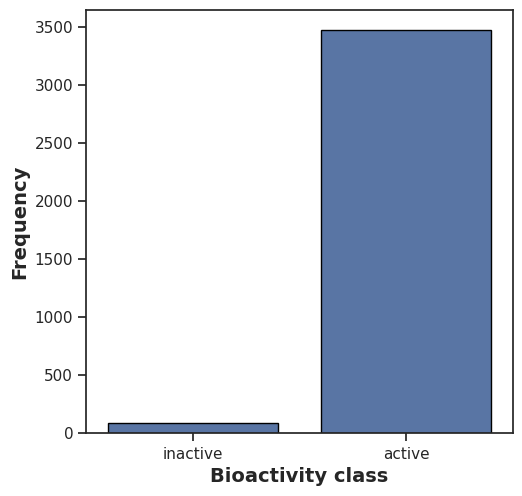

In [ ]:
plt.figure(figsize=(5.5, 5.5))

sns.countplot(x='class', data=df_2class, edgecolor='black')

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('Frequency', fontsize=14, fontweight='bold')

plt.savefig('plot_bioactivity_class.pdf')

### **Scatter plot of MW versus LogP**

It can be seen that the 2 bioactivity classes are spanning similar chemical spaces as evident by the scatter plot of MW vs LogP.

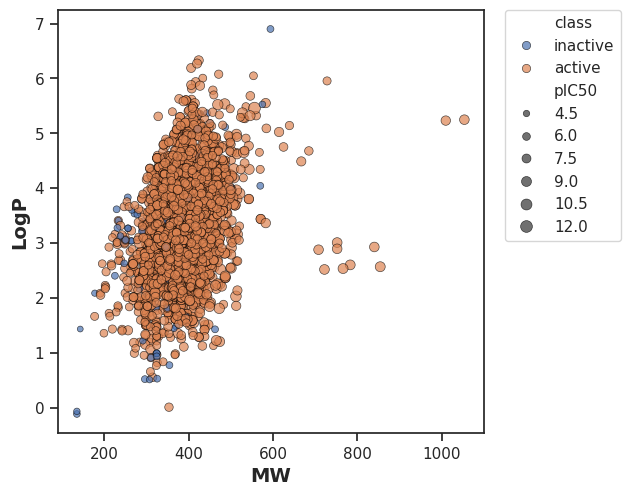

In [ ]:
plt.figure(figsize=(5.5, 5.5))

sns.scatterplot(x='MW', y='LogP', data=df_2class, hue='class', size='pIC50', edgecolor='black', alpha=0.7)

plt.xlabel('MW', fontsize=14, fontweight='bold')
plt.ylabel('LogP', fontsize=14, fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0)
plt.savefig('plot_MW_vs_LogP.pdf')

### **Box plots**

#### **pIC50 value**

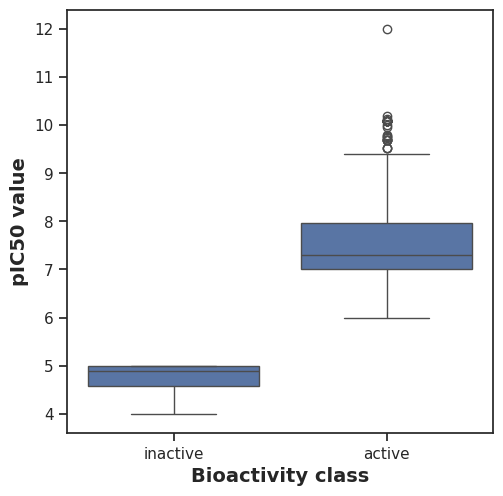

In [ ]:
plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x = 'class', y = 'pIC50', data = df_2class)

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('pIC50 value', fontsize=14, fontweight='bold')

plt.savefig('plot_ic50.pdf')

**Statistical analysis | Mann-Whitney U Test**

In [ ]:
def mannwhitney(descriptor, verbose=False):
  # https://machinelearningmastery.com/nonparametric-statistical-significance-tests-in-python/
  from numpy.random import seed
  from numpy.random import randn
  from scipy.stats import mannwhitneyu

# seed the random number generator
  seed(1)

# actives and inactives
  selection = [descriptor, 'class']
  df = df_2class[selection]
  active = df[df['class'] == 'active']
  active = active[descriptor]

  selection = [descriptor, 'class']
  df = df_2class[selection]
  inactive = df[df['class'] == 'inactive']
  inactive = inactive[descriptor]

# compare samples
  stat, p = mannwhitneyu(active, inactive)
  #print('Statistics=%.3f, p=%.3f' % (stat, p))

# interpret
  alpha = 0.05
  if p > alpha:
    interpretation = 'Same distribution (fail to reject H0)'
  else:
    interpretation = 'Different distribution (reject H0)'

  results = pd.DataFrame({'Descriptor':descriptor,
                          'Statistics':stat,
                          'p':p,
                          'alpha':alpha,
                          'Interpretation':interpretation}, index=[0])
  filename = 'mannwhitneyu_' + descriptor + '.csv'
  results.to_csv(filename)

  return results

In [ ]:
mannwhitney('pIC50')

,Descriptor,Statistics,p,alpha,Interpretation
0,pIC50,295375.0,3.964530e-56,0.05,Different distribution (reject H0)


#### **MW**

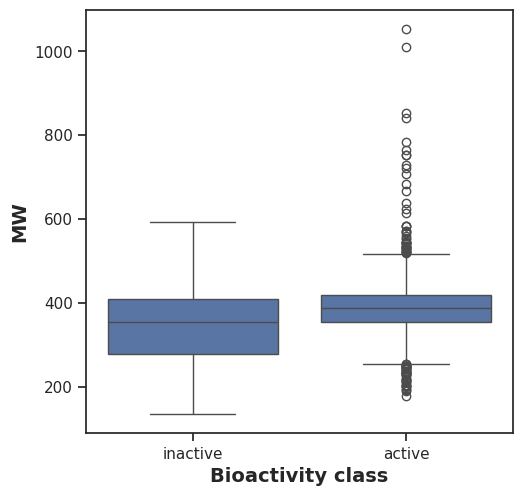

In [ ]:
plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x = 'class', y = 'MW', data = df_2class)

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('MW', fontsize=14, fontweight='bold')

plt.savefig('plot_MW.pdf')

In [ ]:
mannwhitney('MW')

,Descriptor,Statistics,p,alpha,Interpretation
0,MW,189920.0,0.000006,0.05,Different distribution (reject H0)


#### **LogP**

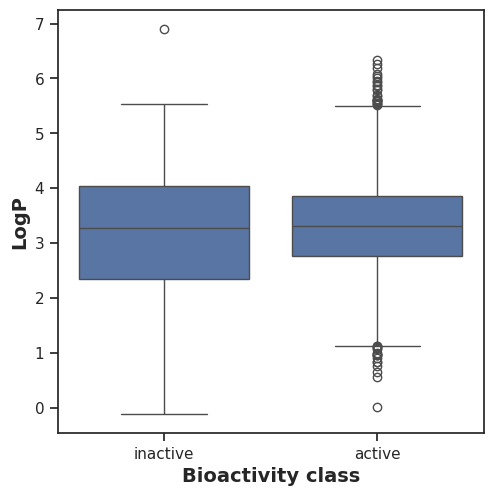

In [ ]:
plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x = 'class', y = 'LogP', data = df_2class)

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('LogP', fontsize=14, fontweight='bold')

plt.savefig('plot_LogP.pdf')

**Statistical analysis | Mann-Whitney U Test**

In [ ]:
mannwhitney('LogP')

,Descriptor,Statistics,p,alpha,Interpretation
0,LogP,151008.5,0.722839,0.05,Same distribution (fail to reject H0)


#### **NumHDonors**

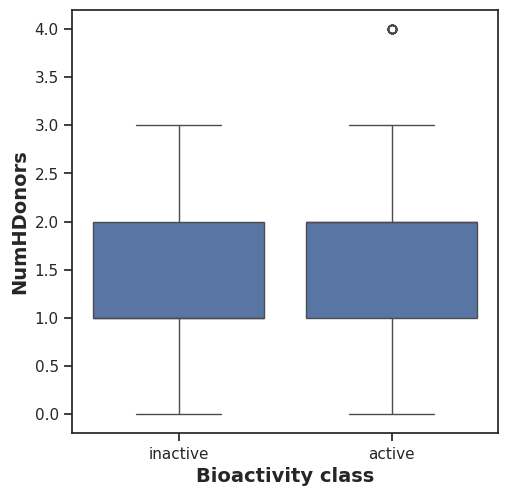

In [ ]:
plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x = 'class', y = 'NumHDonors', data = df_2class)

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('NumHDonors', fontsize=14, fontweight='bold')

plt.savefig('plot_NumHDonors.pdf')

**Statistical analysis | Mann-Whitney U Test**

In [ ]:
mannwhitney('NumHDonors')

,Descriptor,Statistics,p,alpha,Interpretation
0,NumHDonors,154829.5,0.406144,0.05,Same distribution (fail to reject H0)


#### **NumHAcceptors**

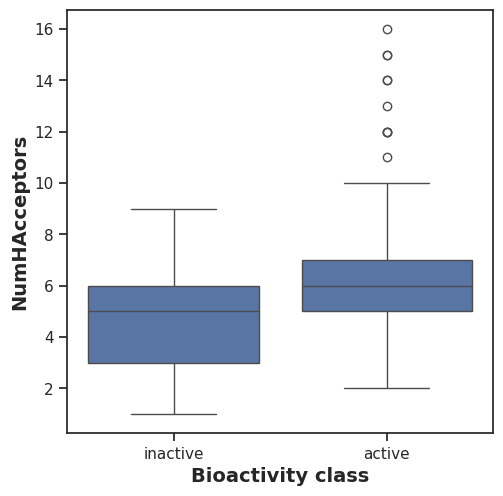

In [ ]:
plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x = 'class', y = 'NumHAcceptors', data = df_2class)

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('NumHAcceptors', fontsize=14, fontweight='bold')

plt.savefig('plot_NumHAcceptors.pdf')

In [ ]:
mannwhitney('NumHAcceptors')

,Descriptor,Statistics,p,alpha,Interpretation
0,NumHAcceptors,194932.5,2.005133e-07,0.05,Different distribution (reject H0)


#### **Interpretation of Statistical Results**

##### **Box Plots**

###### **pIC50 values**

Taking a look at pIC50 values, the **actives** and **inactives** displayed ***statistically significant difference***, which is to be expected since threshold values (``IC50 < 1,000 nM = Actives while IC50 > 10,000 nM = Inactives``, corresponding to ``pIC50 > 6 = Actives and pIC50 < 5 = Inactives``) were used to define actives and inactives.

###### **Lipinski's descriptors**

All of the 4 Lipinski's descriptors exhibited ***statistically significant difference*** between the **actives** and **inactives**.

## **Zip files**

In [ ]:
! zip -r results.zip . -i *.csv *.pdf

updating: plot_bioactivity_class.pdf (deflated 38%)
updating: plot_ic50.pdf (deflated 36%)
updating: plot_NumHDonors.pdf (deflated 38%)
updating: plot_MW_vs_LogP.pdf (deflated 2%)
updating: mannwhitneyu_MW.csv (deflated 8%)
updating: plot_NumHAcceptors.pdf (deflated 37%)
updating: mannwhitneyu_LogP.csv (deflated 8%)
updating: LRRK2_05_bioactivity_data_2class_pIC50.csv (deflated 79%)
updating: mannwhitneyu_NumHAcceptors.csv (deflated 11%)
updating: mannwhitneyu_pIC50.csv (deflated 11%)
updating: mannwhitneyu_NumHDonors.csv (deflated 11%)
updating: plot_MW.pdf (deflated 37%)
updating: plot_LogP.pdf (deflated 36%)
updating: LRRK2_04_bioactivity_data_3class_pIC50.csv (deflated 79%)
